![](carcrash.jpg)

# How do crash data compare between young and elderly drivers?

Philadelphia is one of the largest cities in the United States, and it is prone to recording tens of thousands of automobile crashes every year. As a student who attends school in Philadelphia, I am concerned about the high number of crashes that occur in the city each year. Specifically, since I live on a college campus, I am worried about young drivers being reckless on the road. With these concerns in mind, I decided to analyze Philadelphia's crash data to compare how young and elderly drivers fare on the road. 

The age contrast also prompted me to consider whether these groups differ significantly in crash frequency, crash severity, and whether factors like time of day influence them. I decided to compare young and elderly drivers because both groups are stereotyped as unskilled, reckless, or unsafe.

To begin the analysis, I calculated which age group has the most recordered number of crashes using historical Philadelphia crash data from 2005 to 2024. The data can be accessed [here](https://commjhub.asc.upenn.edu/user/nmaharaj28/lab/tree/comm3180_S26/08_DOW4_and_Geolocated_data_with_GeoPandas/data/PDOT_crash_data_2005_2024.csv). 

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [4]:
crash_data = pd.read_csv('PDOT_crash_data_2005_2024.csv', low_memory=False)

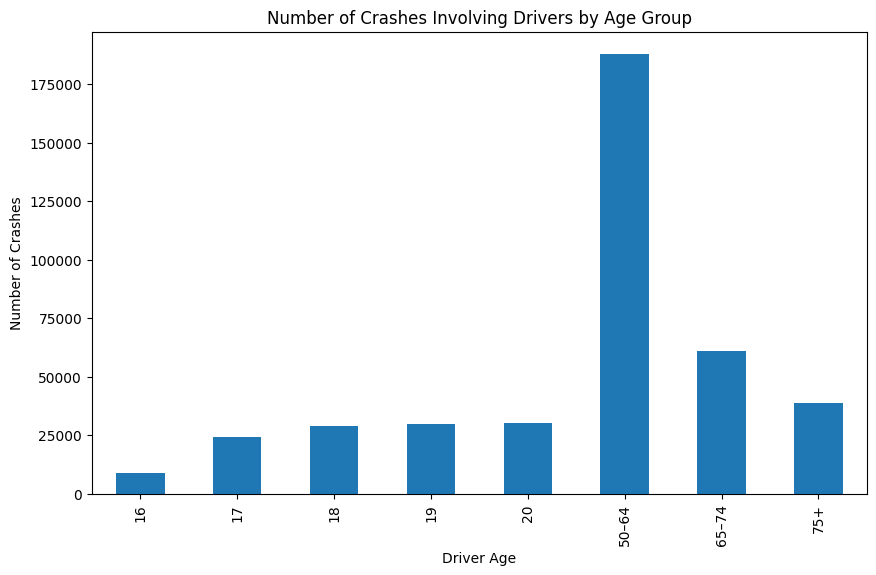

In [16]:
age_crash_counts = {label: (crash_data[col] > 0).sum() for col, label in age_labels.items()}
age_counts_df = pd.DataFrame.from_dict(age_crash_counts, orient='index', columns=['Crash Count'])

age_counts_df.plot(kind='bar',
                   figsize=(10, 6),
                   legend=False)

plt.title('Number of Crashes Involving Drivers by Age Group')
plt.xlabel('Driver Age')
plt.ylabel('Number of Crashes')
plt.show()

In the bar graph above, you can see how the number of crashes compares across various age groups. The dataset separates teenagers but groups elder drivers in three categories: 50-64, 65-75, and 75+. The 50-64 age group has the highest number of crashes, with over 175,000. However, when you compare this number with the total number of crashes from young drivers (16-20), you get 121,723. Both young drivers and 50-64 drivers have comparable numbers, but ultimately, older drivers are involved in more car crashes. This is shocking, as the stereotype of the young, reckless driver is stronger than older drivers being more accident prone.

## How does crash severity compare between the age groups?

Next, I decided to analyze the severity of crashes among young and older drivers. While it is easy to make a simple comparison and identify which group has the most crashes, it is important to assess how these crashes compare in severity. 

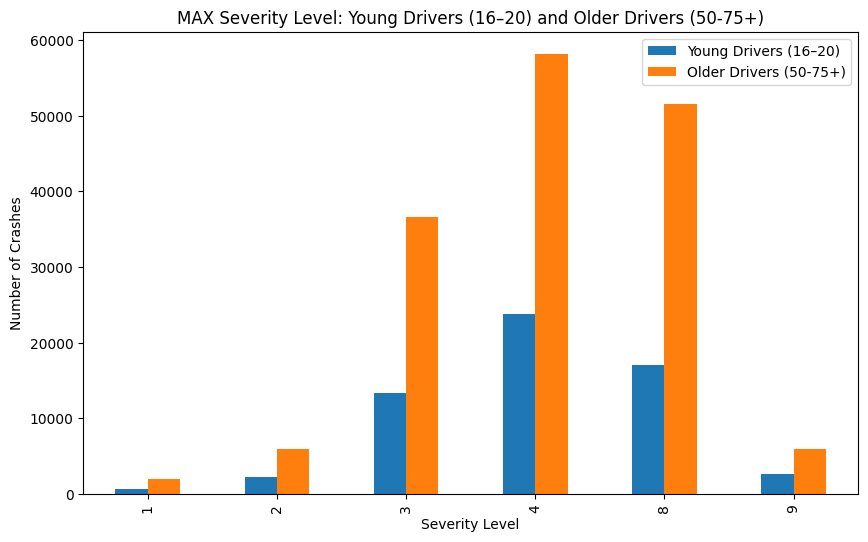

In [24]:
young_filter = crash_data[['DRIVER_COUNT_16YR', 'DRIVER_COUNT_17YR', 'DRIVER_COUNT_18YR', 'DRIVER_COUNT_19YR', 'DRIVER_COUNT_20YR']].sum(axis=1) > 0
older_filter = crash_data[['DRIVER_COUNT_50_64YR', 'DRIVER_COUNT_65_74YR', 'DRIVER_COUNT_75PLUS']].sum(axis=1) > 0

young_crashes = crash_data[young_filter]
older_crashes = crash_data[older_filter]

young_severity = young_crashes[young_crashes['MAX_SEVERITY_LEVEL'] > 0]['MAX_SEVERITY_LEVEL'].value_counts().sort_index()
older_severity = older_crashes[older_crashes['MAX_SEVERITY_LEVEL'] > 0]['MAX_SEVERITY_LEVEL'].value_counts().sort_index()

severity_df = pd.DataFrame({
    'Young Drivers (16–20)': young_severity,
    'Older Drivers (50-75+)': older_severity
})

severity_df.plot(kind='bar',
                 figsize=(10, 6))
plt.title('MAX Severity Level: Young Drivers (16–20) and Older Drivers (50-75+)')
plt.xlabel('Severity Level')
plt.ylabel('Number of Crashes')
plt.show()

## How does time of crash compare between the age groups?

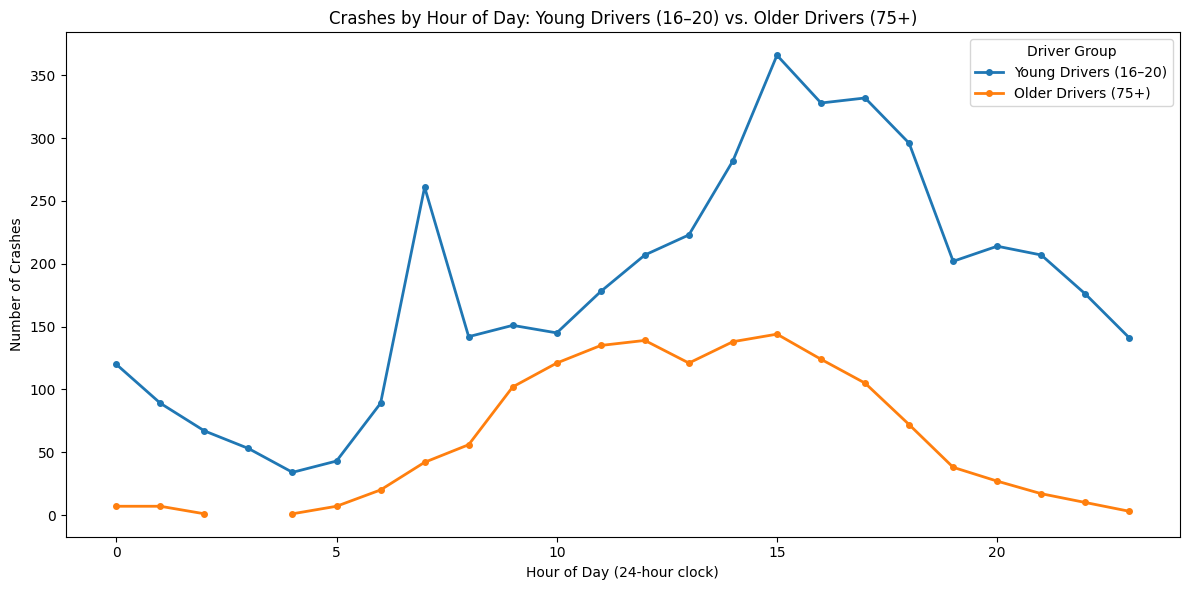

In [10]:
young_hour = young_crashes[young_crashes['HOUR_OF_DAY'] != 99]['HOUR_OF_DAY'].value_counts().sort_index()
older_hour = older_crashes[older_crashes['HOUR_OF_DAY'] != 99]['HOUR_OF_DAY'].value_counts().sort_index()

hour_df = pd.DataFrame({
    'Young Drivers (16–20)': young_hour,
    'Older Drivers (75+)': older_hour
})

hour_df.plot(kind='line',
             figsize=(12, 6),
             linewidth=2,
             marker='o',
             markersize=4)

plt.title('Crashes by Hour of Day: Young Drivers (16–20) vs. Older Drivers (75+)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crashes')
plt.legend(title='Driver Group')
plt.tight_layout()
plt.show()

In [ ]:
Crashes by DAY_OF_WEEK — weekday vs. weekend split
Crashes by CRASH_MONTH — seasonal trends

In [8]:
crash_data['DAY_OF_WEEK'].value_counts().sort_index()

DAY_OF_WEEK
1     83804
2     94204
3     98996
4    100527
5    100881
6    113384
7     99273
Name: count, dtype: int64

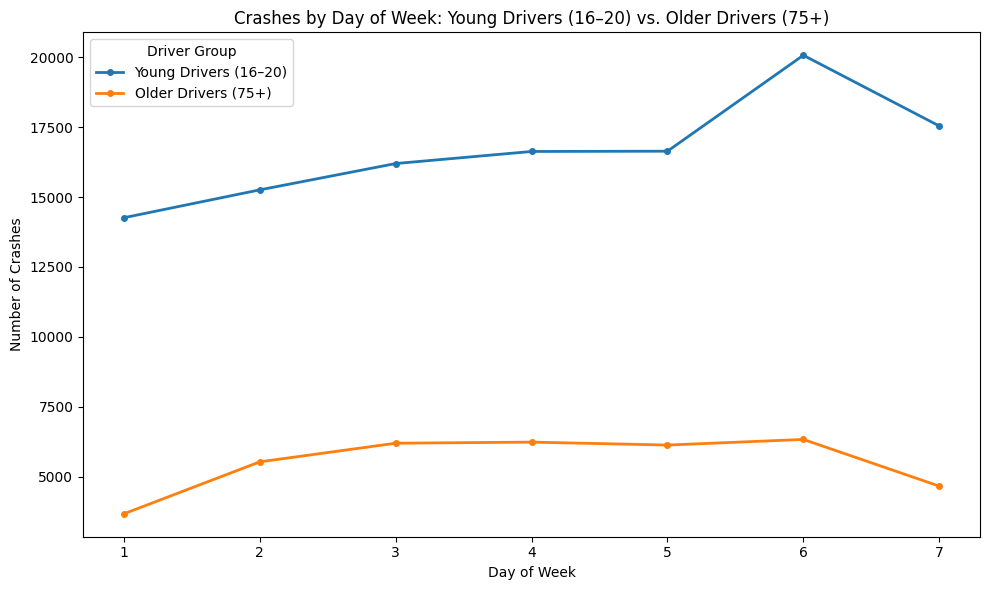

In [14]:
young_dow = young_crashes['DAY_OF_WEEK'].value_counts().sort_index()
older_dow = older_crashes['DAY_OF_WEEK'].value_counts().sort_index()

dow_df = pd.DataFrame({
    'Young Drivers (16–20)': young_dow,
    'Older Drivers (75+)': older_dow
})

dow_df.plot(kind='line',
            figsize=(10, 6),
            linewidth=2,
            marker='o',
            markersize=4)

plt.title('Crashes by Day of Week: Young Drivers (16–20) vs. Older Drivers (75+)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Crashes')
plt.legend(title='Driver Group')
plt.tight_layout()
plt.show()